# 🚀 Mini Project 1: House Price Analysis & Outlier Detection

In [1]:
print("Hello World")

Hello World


In [2]:
%pip install pandas numpy scipy matplotlib seaborn scikit-learn

In [3]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [8]:
data.target_names

['MedHouseVal']

In [9]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='MedInc', ylabel='Count'>

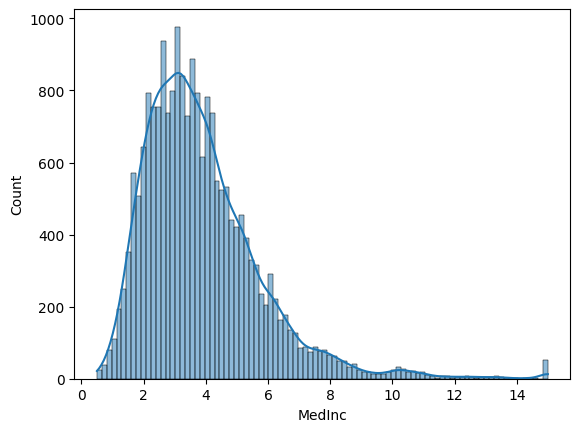

In [12]:
sns.histplot(df['MedInc'], kde=True)

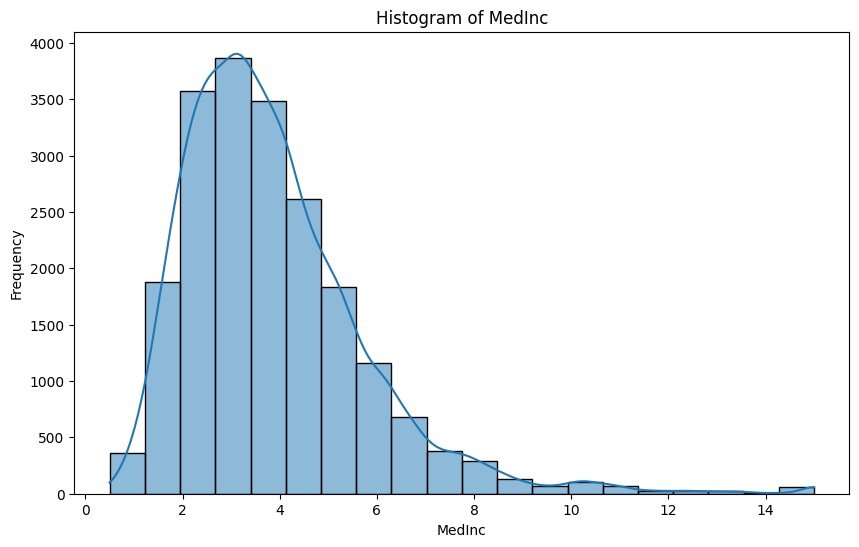

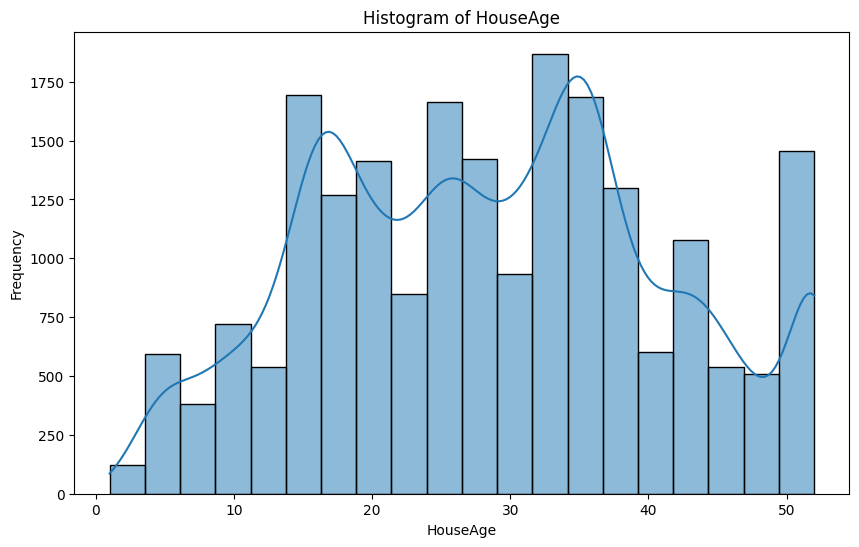

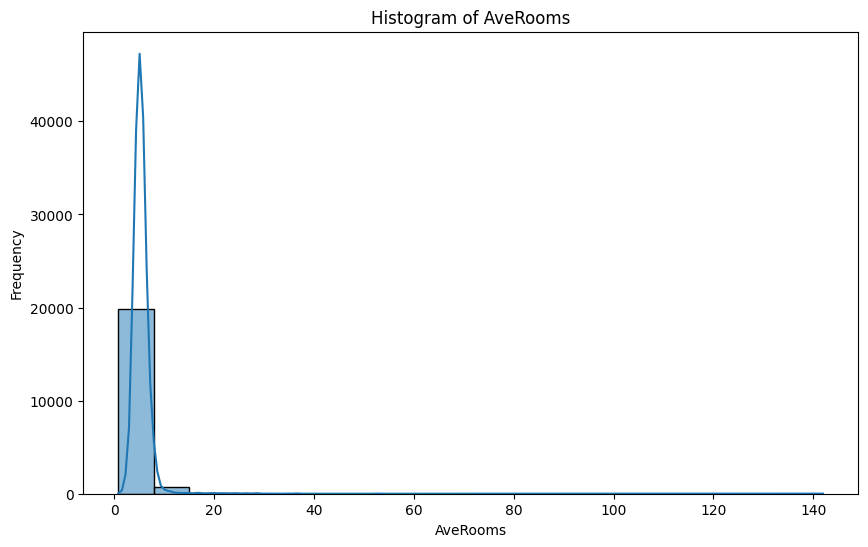

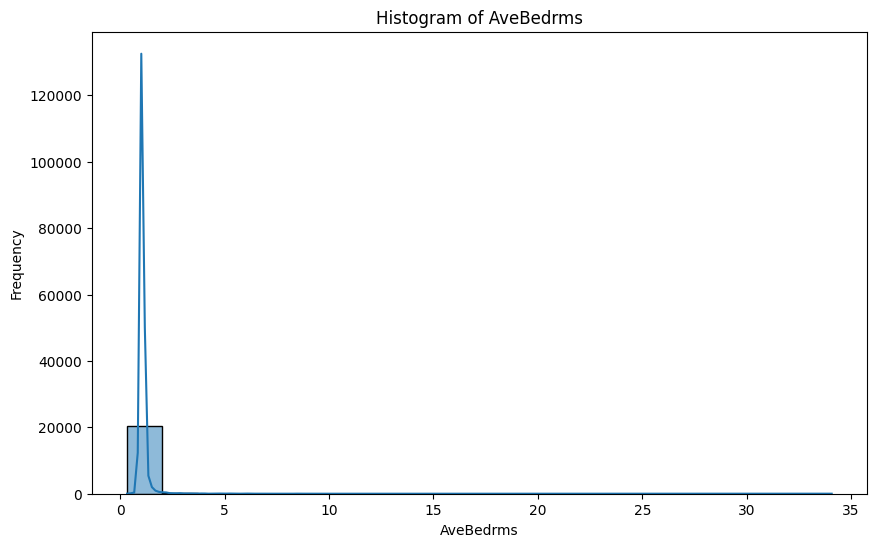

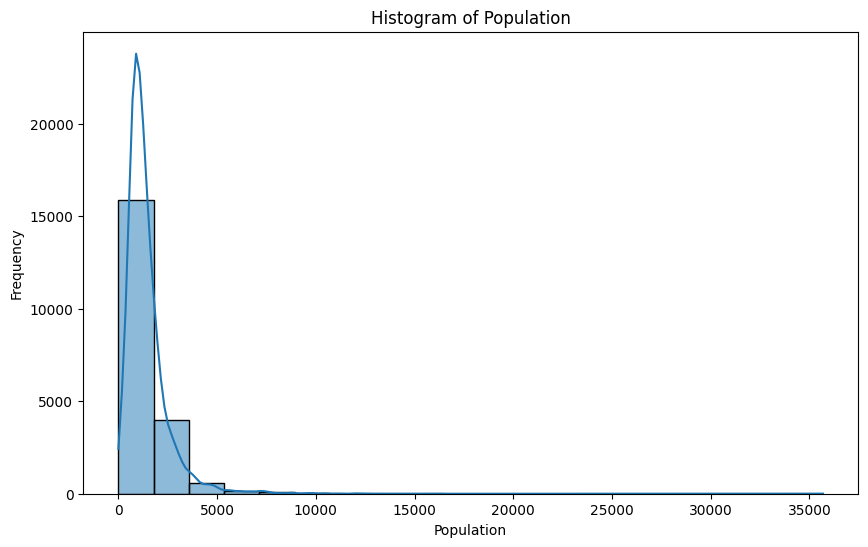

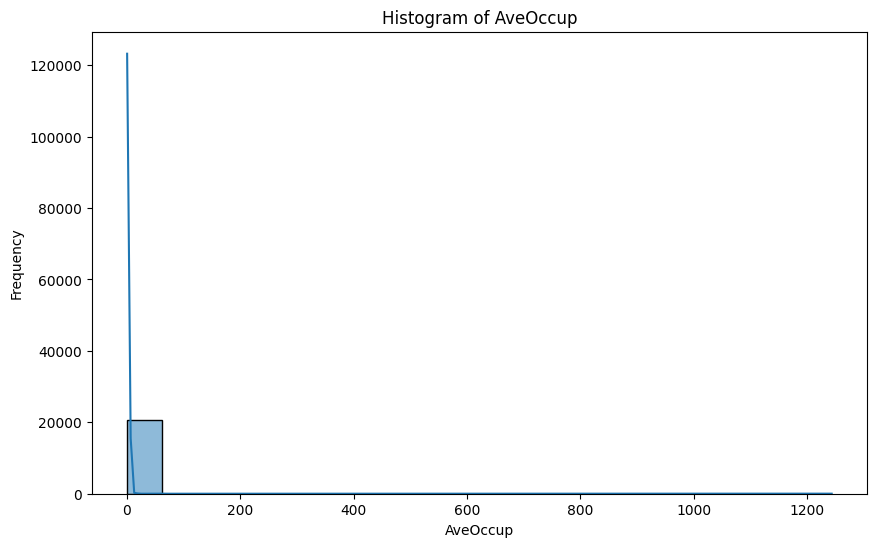

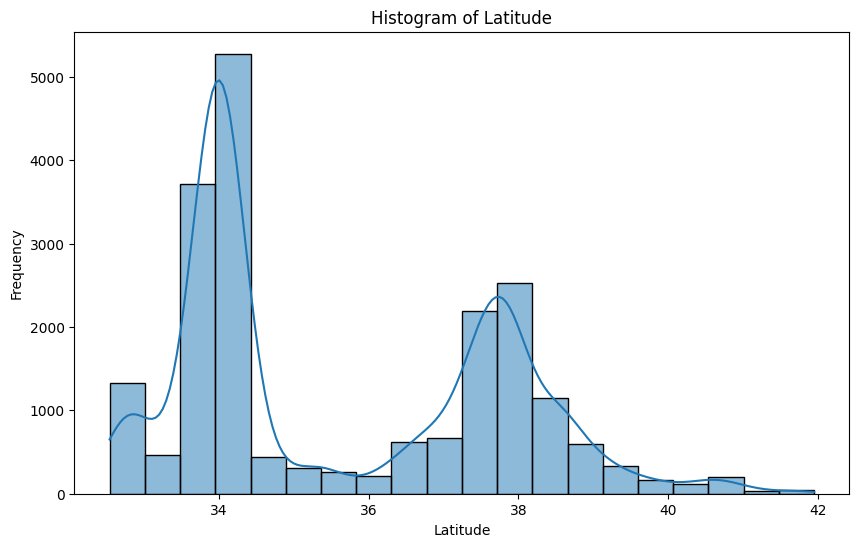

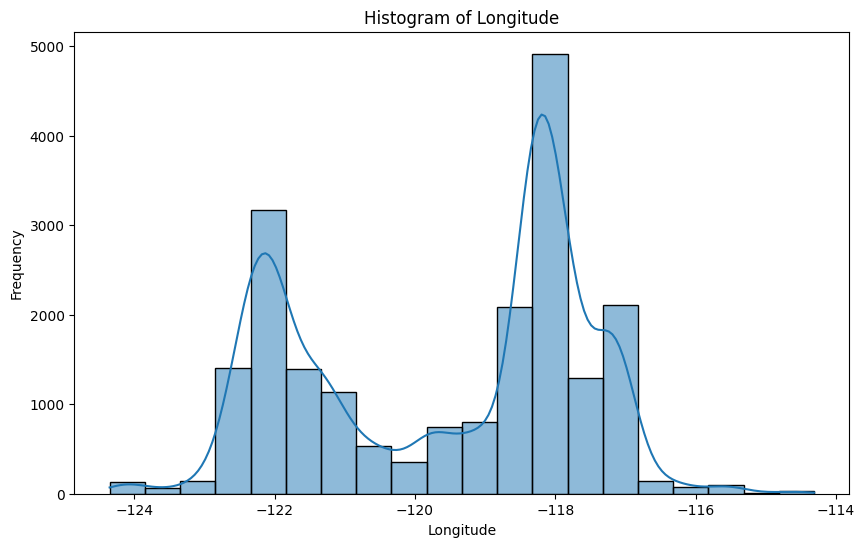

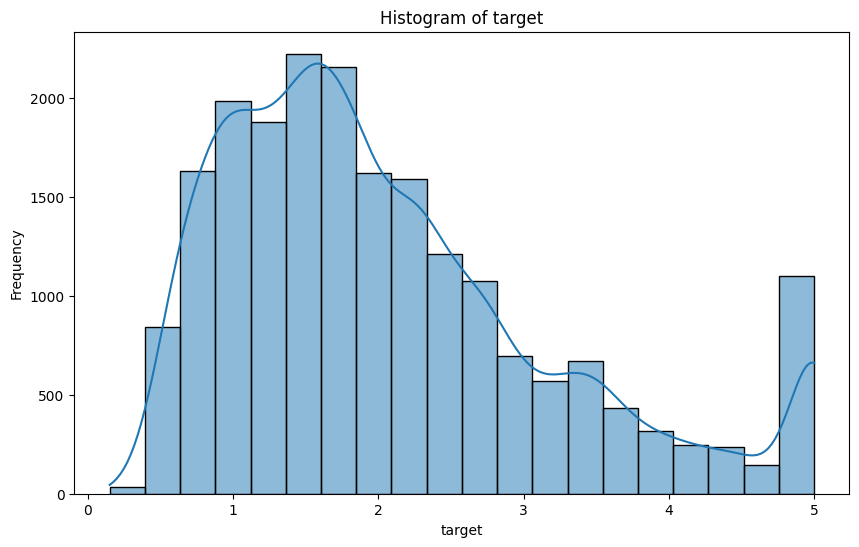

In [15]:
# hist plot for every numerical feature
for column in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], bins=20, edgecolor='black', linewidth=1,kde=True)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()


In [16]:
from scipy.stats import skew, kurtosis

In [17]:
print("Skewness:",skew(df['MedInc']))
print("Kurtosis:",kurtosis(df['MedInc']))

Skewness: 1.64653702990008
Kurtosis: 4.951033760409659



### Skewness: 
- A measure of the asymmetry of a distribution. Positive means right skewed, negative means left skewed, and zero means symmetric.
- In our case, a skewness value greater than zero means that our distribution is more likely to be on the right side relative to the center.

### Kurtosis: 
- A measure of the "tailedness" of a distribution. Positive values indicate that a distribution is more peaked (i.e., has heavier tails), while negative values indicate that a distribution is more flat (i.e., has lighter tails). 
- In our case, a Kurtosis value greater than zero means that our distribution is more peaked. 


In [18]:
print("Kurtosis for Population:",kurtosis(df['Population']))

Kurtosis for Population: 73.53500881922278


In [ ]:
from scipy import stats
import numpy as np


In [ ]:
z_scores=np.abs(stats.zscore(df))

array([[2.34476576, 0.98214266, 0.62855945, ..., 1.05254828, 1.32783522,
        2.12963148],
       [2.33223796, 0.60701891, 0.32704136, ..., 1.04318455, 1.32284391,
        1.31415614],
       [1.7826994 , 1.85618152, 1.15562047, ..., 1.03850269, 1.33282653,
        1.25869341],
       ...,
       [1.14259331, 0.92485123, 0.09031802, ..., 1.77823747, 0.8237132 ,
        0.99274649],
       [1.05458292, 0.84539315, 0.04021111, ..., 1.77823747, 0.87362627,
        1.05860847],
       [0.78012947, 1.00430931, 0.07044252, ..., 1.75014627, 0.83369581,
        1.01787803]])

In [24]:
z_scores[0]


array([2.34476576, 0.98214266, 0.62855945, 0.15375759, 0.9744286 ,
       0.04959654, 1.05254828, 1.32783522, 2.12963148])

In [28]:
outliers=z_scores > 3
outliers

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [29]:
df_outliers=df[outliers]

In [30]:
df_outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
131,11.6017,18.0,8.335052,1.082474,533.0,2.747423,37.84,-122.19,3.92600
283,5.9849,22.0,6.528724,1.041179,4985.0,2.534316,37.79,-122.16,3.71000
409,10.0825,52.0,8.209016,1.024590,658.0,2.696721,37.90,-122.28,3.97000
510,11.8603,39.0,7.911111,0.984127,808.0,2.565079,37.82,-122.22,5.00001
511,13.4990,42.0,8.928358,1.000000,1018.0,3.038806,37.82,-122.22,5.00001
...,...,...,...,...,...,...,...,...,...
20529,2.9605,12.0,4.915341,1.022451,5633.0,2.634705,38.55,-121.78,2.04300
20530,3.1371,11.0,5.070223,1.015530,7984.0,2.695476,38.57,-121.76,2.01800
20544,2.0650,23.0,4.803493,1.013646,6330.0,3.455240,38.55,-121.76,2.19400
20563,3.1250,9.0,5.148007,1.119593,6837.0,2.899491,38.67,-121.75,1.32500


In [43]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df))

outliers = (z_scores > 3)
df_outliers = df[outliers.any(axis=1)]

print("Outliers:", df_outliers.shape)

Outliers: (846, 9)


In [50]:
df_clean = df[(z_scores < 3).all(axis=1)]
print(df_clean.shape)

(19794, 9)


<Axes: xlabel='MedInc', ylabel='Count'>

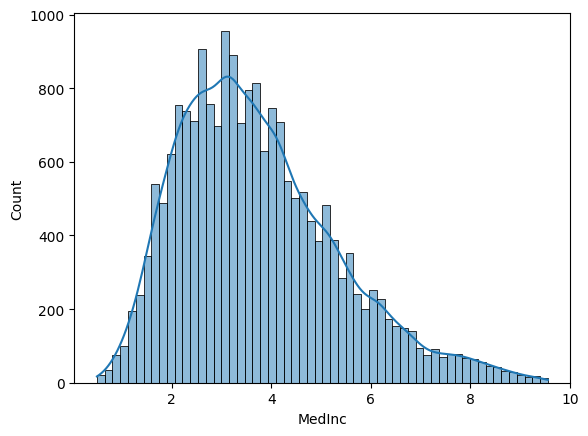

In [51]:
sns.histplot(df_clean["MedInc"],kde=True)

In [53]:
# getting write skewd

df_clean.loc[:, 'MedInc'] = np.log(df_clean['MedInc'])

In [54]:
df_clean['MedInc']

,MedInc
0,2.119287
1,2.116424
2,1.982022
3,1.730434
4,1.347086
...,...
20635,0.444878
20636,0.938756
20637,0.530628
20638,0.624440


<Axes: xlabel='MedInc', ylabel='Count'>

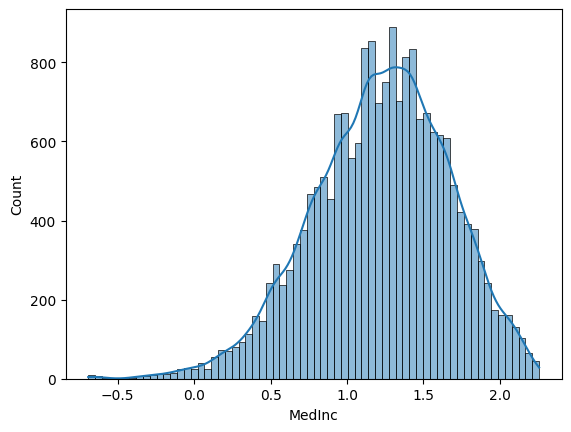

In [56]:
sns.histplot(df_clean['MedInc'],kde=True)

In [60]:
# feature scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_clean_scaled = scaler.fit_transform(df_clean)
df_clean_scaled

array([[ 2.00573429,  0.96629447,  1.42494775, ...,  1.0499792 ,
        -1.320935  ,  2.25737618],
       [ 1.9993326 , -0.64040157,  0.81426021, ...,  1.04062055,
        -1.31594443,  1.40774788],
       [ 1.69879515,  1.84997729,  2.49244452, ...,  1.03594122,
        -1.32592557,  1.34996233],
       ...,
       [-1.54666496, -0.96174078, -0.0310495 , ...,  1.7752746 ,
        -0.81688757, -0.99577021],
       [-1.33689259, -0.88140598,  0.07043584, ...,  1.7752746 ,
        -0.86679325, -1.06439056],
       [-0.78621408, -1.04207558,  0.00920588, ...,  1.74719865,
        -0.8268687 , -1.02195429]])

In [61]:
scaled_data[0]

array([ 2.00573429,  0.96629447,  1.42494775, -0.33359954, -1.25951959,
       -0.42466819,  1.0499792 , -1.320935  ,  2.25737618])

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Use the scaled data for training
X = df_clean_scaled  # Use scaled features
y = df_clean['target']  # Target remains the same

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [63]:
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [64]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


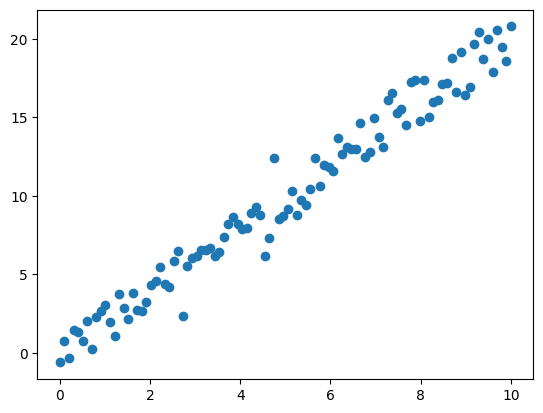

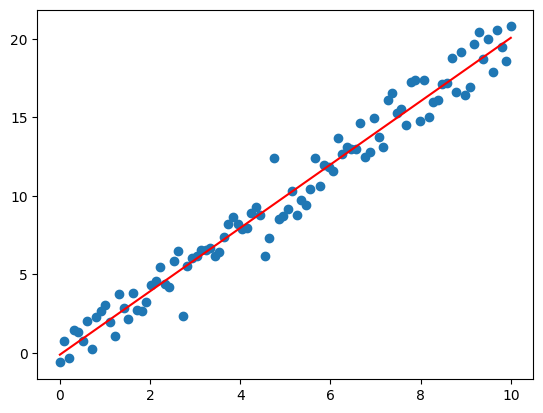

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def generate_data(n):
    x = np.linspace(0, 10, n)
    y = 2 * x + np.random.normal(0, 1, n)
    return x, y

x, y = generate_data(100)

plt.scatter(x, y)
plt.show()

# Fit a line to the data
m, b = np.polyfit(x, y, 1)

# Make predictions
x_pred = np.linspace(0, 10, 100)
y_pred = m * x_pred + b

# Plot the data and predictions
plt.scatter(x, y)
plt.plot(x_pred, y_pred, color='r')
plt.show()



# 🚧 Upgrade This Project (Pro Level)

If you want to stand out:

### 1. Add Visualization Dashboard

* Compare before vs after cleaning

### 2. Compare Models

* Before preprocessing vs after

### 3. Use Advanced Outlier Methods

* IQR method
* Isolation Forest

### 4. Feature Engineering

* Create new features using mean/std

---

# 🧪 Challenge Tasks (Do These)

### Task 1

Find:

* Which column is most skewed?

---

### Task 2

Compare:

* Model accuracy **before vs after removing outliers**

---

### Task 3

Plot:

* Distribution before vs after log transform

---

### Task 4 (Important)

Try:

```python
df['feature'] = (df['feature'] - df['feature'].mean()) / df['feature'].std()
```

→ manually implement z-score

---

# ⚠️ Honest Reality

If you can:

* Explain why you used z-score
* Justify removing outliers
* Show before/after improvement

👉 You are already above most entry-level candidates.
 